In [11]:
import pandas as pd
import re
import string
import spacy
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Step 1: Load data
column_names = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job_title',
    'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts',
    'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context'
]

train_df = pd.read_csv('train.tsv', sep='\t', header=None, names=column_names)
test_df = pd.read_csv('test.tsv', sep='\t', header=None, names=column_names)
valid_df = pd.read_csv('valid.tsv', sep='\t', header=None, names=column_names)
train_df = pd.concat([train_df, valid_df])



In [12]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 11524 entries, 0 to 1283
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    11524 non-null  object 
 1   label                 11524 non-null  object 
 2   statement             11524 non-null  object 
 3   subject               11522 non-null  object 
 4   speaker               11522 non-null  object 
 5   speaker_job_title     8281 non-null   object 
 6   state_info            9035 non-null   object 
 7   party_affiliation     11522 non-null  object 
 8   barely_true_counts    11522 non-null  float64
 9   false_counts          11522 non-null  float64
 10  half_true_counts      11522 non-null  float64
 11  mostly_true_counts    11522 non-null  float64
 12  pants_on_fire_counts  11522 non-null  float64
 13  context               11410 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.3+ MB
None


In [13]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    1267 non-null   object
 1   label                 1267 non-null   object
 2   statement             1267 non-null   object
 3   subject               1267 non-null   object
 4   speaker               1267 non-null   object
 5   speaker_job_title     942 non-null    object
 6   state_info            1005 non-null   object
 7   party_affiliation     1267 non-null   object
 8   barely_true_counts    1267 non-null   int64 
 9   false_counts          1267 non-null   int64 
 10  half_true_counts      1267 non-null   int64 
 11  mostly_true_counts    1267 non-null   int64 
 12  pants_on_fire_counts  1267 non-null   int64 
 13  context               1250 non-null   object
dtypes: int64(5), object(9)
memory usage: 138.7+ KB
None


In [14]:
print(valid_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1284 entries, 0 to 1283
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    1284 non-null   object
 1   label                 1284 non-null   object
 2   statement             1284 non-null   object
 3   subject               1284 non-null   object
 4   speaker               1284 non-null   object
 5   speaker_job_title     939 non-null    object
 6   state_info            1005 non-null   object
 7   party_affiliation     1284 non-null   object
 8   barely_true_counts    1284 non-null   int64 
 9   false_counts          1284 non-null   int64 
 10  half_true_counts      1284 non-null   int64 
 11  mostly_true_counts    1284 non-null   int64 
 12  pants_on_fire_counts  1284 non-null   int64 
 13  context               1272 non-null   object
dtypes: int64(5), object(9)
memory usage: 140.6+ KB
None


In [15]:
label_map = {
    'pants-fire': 'false',
    'false': 'false',
    'barely-true': 'false',
    'half-true': 'true',
    'mostly-true': 'true',
    'true': 'true'
}
train_df['binary_label'] = train_df['label'].map(label_map)
test_df['binary_label'] = test_df['label'].map(label_map)

# Step 2: Manual cleaning & tokenization
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return re.sub(r"\s+", " ", text).strip()

train_df['cleaned'] = train_df['statement'].apply(clean_text)
test_df['cleaned'] = test_df['statement'].apply(clean_text)

# Step 3: Entity extraction using spaCy
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [ent.text for ent in doc.ents if ent.label_ in ['PERSON', 'ORG', 'GPE']]

train_df['entities'] = train_df['statement'].apply(extract_entities)
test_df['entities'] = test_df['statement'].apply(extract_entities)

# Step 4: Build knowledge graph and entity scores
G = nx.Graph()
entity_scores = {}

for _, row in train_df.iterrows():
    ents = row['entities']
    label = row['binary_label']

    # Edges for visualization
    for i in range(len(ents)):
        for j in range(i+1, len(ents)):
            G.add_edge(ents[i], ents[j])

    for ent in ents:
        if ent not in entity_scores:
            entity_scores[ent] = 0
        entity_scores[ent] += 1 if label == 'true' else -1

def predict_graph_based(entities):
    if not entities:
        return 0  # default score
    score = sum(entity_scores.get(e, 0) for e in entities) / len(entities)
    return score

# Step 5: TF-IDF feature extraction
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(train_df['cleaned'])
X_test_tfidf = tfidf.transform(test_df['cleaned'])

# Step 6: Combine TF-IDF with graph-based score
train_df['graph_score'] = train_df['entities'].apply(predict_graph_based)
test_df['graph_score'] = test_df['entities'].apply(predict_graph_based)

# Add as extra feature to TF-IDF vectors
import scipy.sparse as sp
X_train_combined = sp.hstack([X_train_tfidf, train_df['graph_score'].values.reshape(-1, 1)])
X_test_combined = sp.hstack([X_test_tfidf, test_df['graph_score'].values.reshape(-1, 1)])

# Step 7: Train model and evaluate
y_train = train_df['binary_label'].map({'true': 1, 'false': 0})
y_test = test_df['binary_label'].map({'true': 1, 'false': 0})

clf = LogisticRegression(max_iter=300)
clf.fit(X_train_combined, y_train)
y_pred = clf.predict(X_test_combined)

acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy (TF-IDF + Graph): {round(acc*100)}%")


Final Accuracy (TF-IDF + Graph): 63%


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


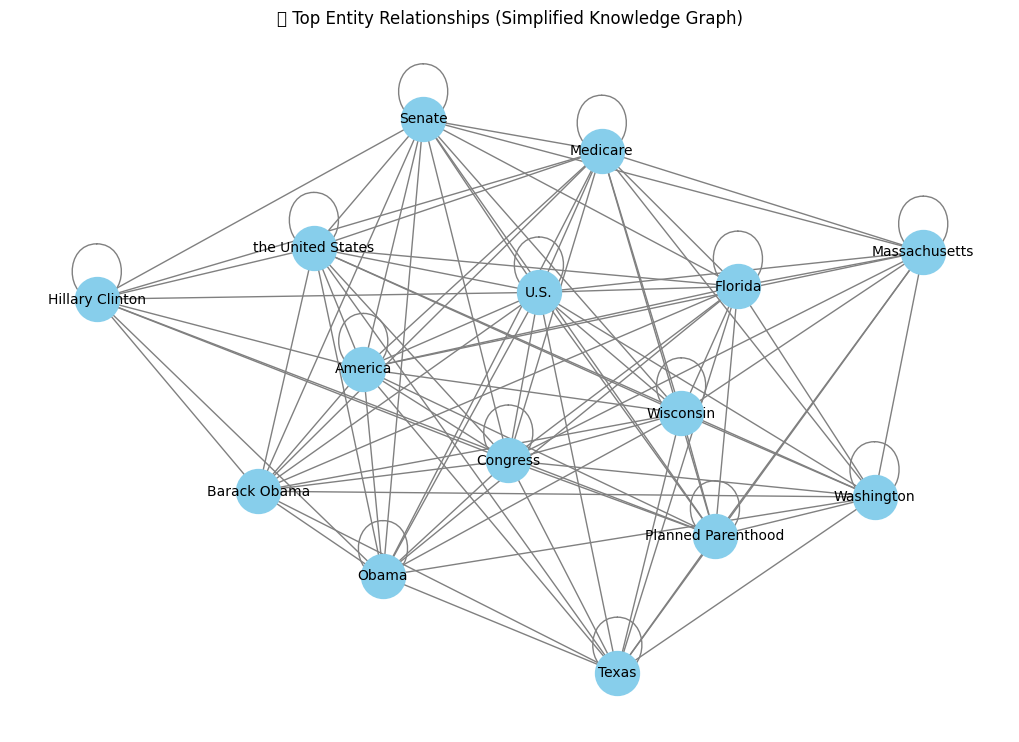

In [16]:
# Show top entities by degree
# Degree here refers to the number of connections (edges) a node (entity) has
top_entities = sorted(G.degree, key=lambda x: x[1], reverse=True)[:15]
# Extract the node names from the top entities for subgraphing
sub_nodes = [node for node, _ in top_entities]
# Create a subgraph containing only the top connected entities
subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(10, 7))
# Compute layout positions for the subgraph
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=1000, font_size=10)
plt.title("🔍 Top Entity Relationships (Simplified Knowledge Graph)")
plt.show()
